# EDA del dataset Sunflower

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM total:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

PyTorch: 2.5.1
CUDA disponible: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM total: 4.0 GB


#### **1. Instalación e importación de librerías**

In [3]:
# Instalamos Roboflow
!pip install roboflow

In [4]:
import os
import cv2
import random
import matplotlib.pyplot as plt

#### **2. Descarga del dataset**

El dataset se descarga desde Roboflow Universe en formato YOLOv8, ya que este formato organiza las imágenes y anotaciones de forma compatible con la librería Ultralytics YOLO.

In [7]:
from roboflow import Roboflow
#from google.colab import userdata

#api_key = userdata.get('RoboflowAPIKey')
api_key = 'dwhYgz2eTrdO3ErRcat6'
rf = Roboflow(api_key=api_key)
project = rf.workspace("raiyan8018").project("sunflower-mn2cr")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sunflower-1 in yolov8:: 100%|██████████████████| 8584/8584 [00:07<00:00, 1154.43it/s]


#### **3. Estructura del dataset**

Se verifica la estructura general del dataset descargado. En formato YOLOv8 se espera encontrar carpetas separadas para entrenamiento, validación y test, junto con el archivo `data.yaml`, que contiene la configuración del dataset.

In [8]:
os.listdir(dataset.location)

['data.yaml',
 'README.dataset.txt',
 'README.roboflow.txt',
 'test',
 'train',
 'valid']

#### **4. Cantidad de imágenes y anotaciones por partición**

Se contabiliza la cantidad de imágenes y archivos de anotación en cada partición del dataset. Esto permite verificar que cada imagen tenga asociado su correspondiente archivo de labels.

In [9]:
# Verificamos cantidad de imágenes para cada set y que cada imagen tenga su label
for split in ["train", "valid", "test"]:
    images_dir = os.path.join(dataset.location, split, "images")
    labels_dir = os.path.join(dataset.location, split, "labels")

    n_images = len(os.listdir(images_dir))
    n_labels = len(os.listdir(labels_dir))

    print(f"{split}: {n_images} imágenes | {n_labels} labels")

train: 3429 imágenes | 3429 labels
valid: 428 imágenes | 428 labels
test: 429 imágenes | 429 labels


#### **5. Distribución de clases**

Se analiza la cantidad de objetos anotados por clase. Aunque el problema se enfoca en una única clase principal, este análisis permite verificar la cantidad total de capítulos de girasol anotados y confirmar que las etiquetas sean consistentes.

In [10]:
import yaml
from collections import Counter

# Leemos el archivo data.yaml para obtener los nombres de las clases
yaml_path = os.path.join(dataset.location, "data.yaml")

with open(yaml_path, "r") as file:
    data_yaml = yaml.safe_load(file)

class_names = data_yaml["names"]

print("Clases del dataset:")
print(class_names)

Clases del dataset:
['Backside-Sunflower', 'Sunflower']


In [11]:
class_counts = Counter()

# Recorremos los archivos de labels y contamos cuántas anotaciones hay por clase
for split in ["train", "valid", "test"]:
    labels_dir = os.path.join(dataset.location, split, "labels")

    for label_file in os.listdir(labels_dir):
        label_path = os.path.join(labels_dir, label_file)

        with open(label_path, "r") as file:
            lines = file.readlines()

        for line in lines:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

print("Cantidad de objetos anotados por clase:")

for class_id, count in class_counts.items():
    print(f"{class_names[class_id]}: {count}")

Cantidad de objetos anotados por clase:
Sunflower: 296243
Backside-Sunflower: 90


El dataset contiene dos clases: `Sunflower` y `Backside-Sunflower`. Sin embargo, se observa un desbalance extremo entre ambas, ya que la clase principal `Sunflower` concentra prácticamente la totalidad de las anotaciones del dataset.

Debido a que el objetivo principal del proyecto es el conteo automático de capítulos de girasol, se evaluará la posibilidad de simplificar el problema a una única clase durante la etapa de entrenamiento, reduciendo complejidad y evitando posibles problemas derivados del desbalance de clases.

#### **6. Inspección visual del dataset**

Se visualizan imágenes del conjunto de entrenamiento junto con sus bounding boxes para analizar manualmente la calidad de las anotaciones, el tamaño de los objetos, las condiciones de iluminación y posibles desafíos para el modelo de detección.

In [12]:
# Directorios de imágenes y labels del conjunto de entrenamiento
train_images_dir = os.path.join(dataset.location, "train", "images")
train_labels_dir = os.path.join(dataset.location, "train", "labels")

# Seleccionamos una imagen aleatoria
image_name = random.choice(os.listdir(train_images_dir))

image_path = os.path.join(train_images_dir, image_name)

label_path = os.path.join(
    train_labels_dir,
    image_name.replace(".jpg", ".txt").replace(".png", ".txt")
)

print("Imagen seleccionada:", image_name)

Imagen seleccionada: MVI_9987-MP4_frame3_jpg.rf.1be30a5ab725d67dfda8244a664a35ef.jpg


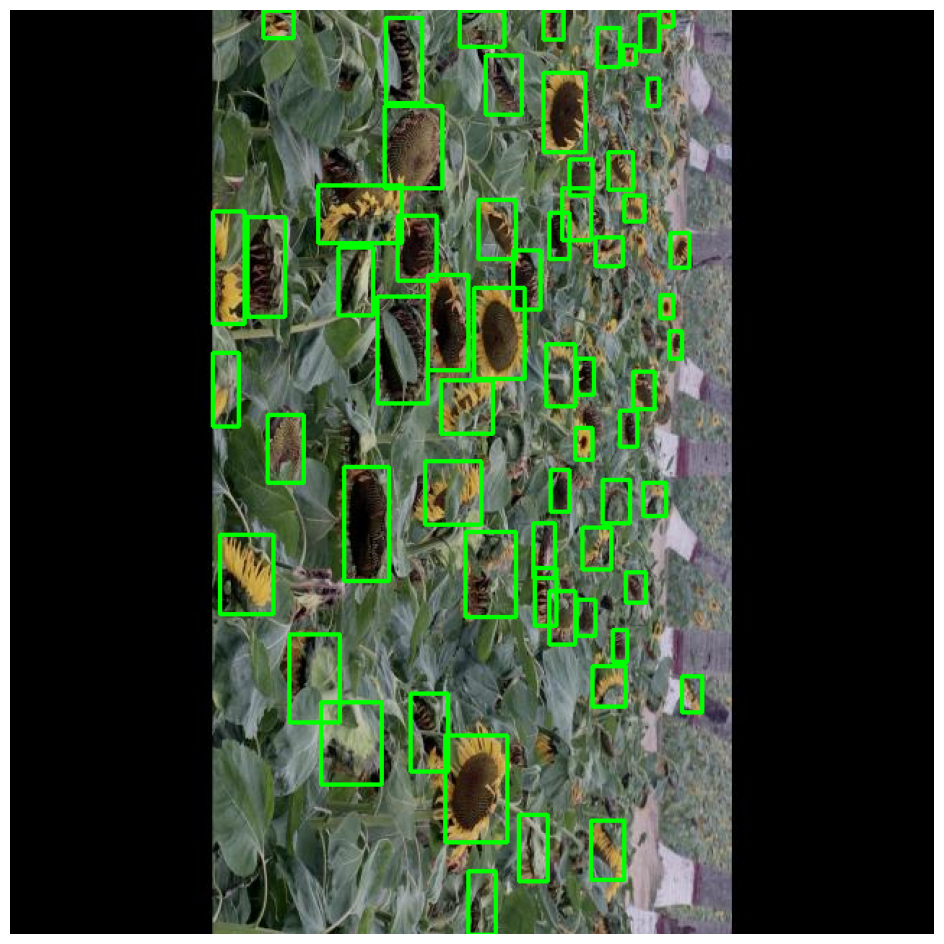

In [13]:
# Leemos la imagen
image = cv2.imread(image_path)

# Convertimos BGR -> RGB para matplotlib
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

img_height, img_width, _ = image.shape

# Leemos las anotaciones
with open(label_path, "r") as file:
    labels = file.readlines()

# Dibujamos bounding boxes
for label in labels:

    class_id, x_center, y_center, width, height = map(float, label.split())

    # Convertimos coordenadas normalizadas a píxeles
    x_center *= img_width
    y_center *= img_height
    width *= img_width
    height *= img_height

    # Calculamos esquinas de la bbox
    x1 = int(x_center - width / 2)
    y1 = int(y_center - height / 2)
    x2 = int(x_center + width / 2)
    y2 = int(y_center + height / 2)

    # Dibujamos rectángulo
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Mostramos imagen
plt.figure(figsize=(12,12))
plt.imshow(image)
plt.axis("off")
plt.show()

**Visualización de múltiples ejemplos**

A continuación se muestran múltiples imágenes aleatorias del conjunto de entrenamiento para analizar la variabilidad visual del dataset, incluyendo iluminación, densidad de capítulos, escalas y posibles oclusiones.

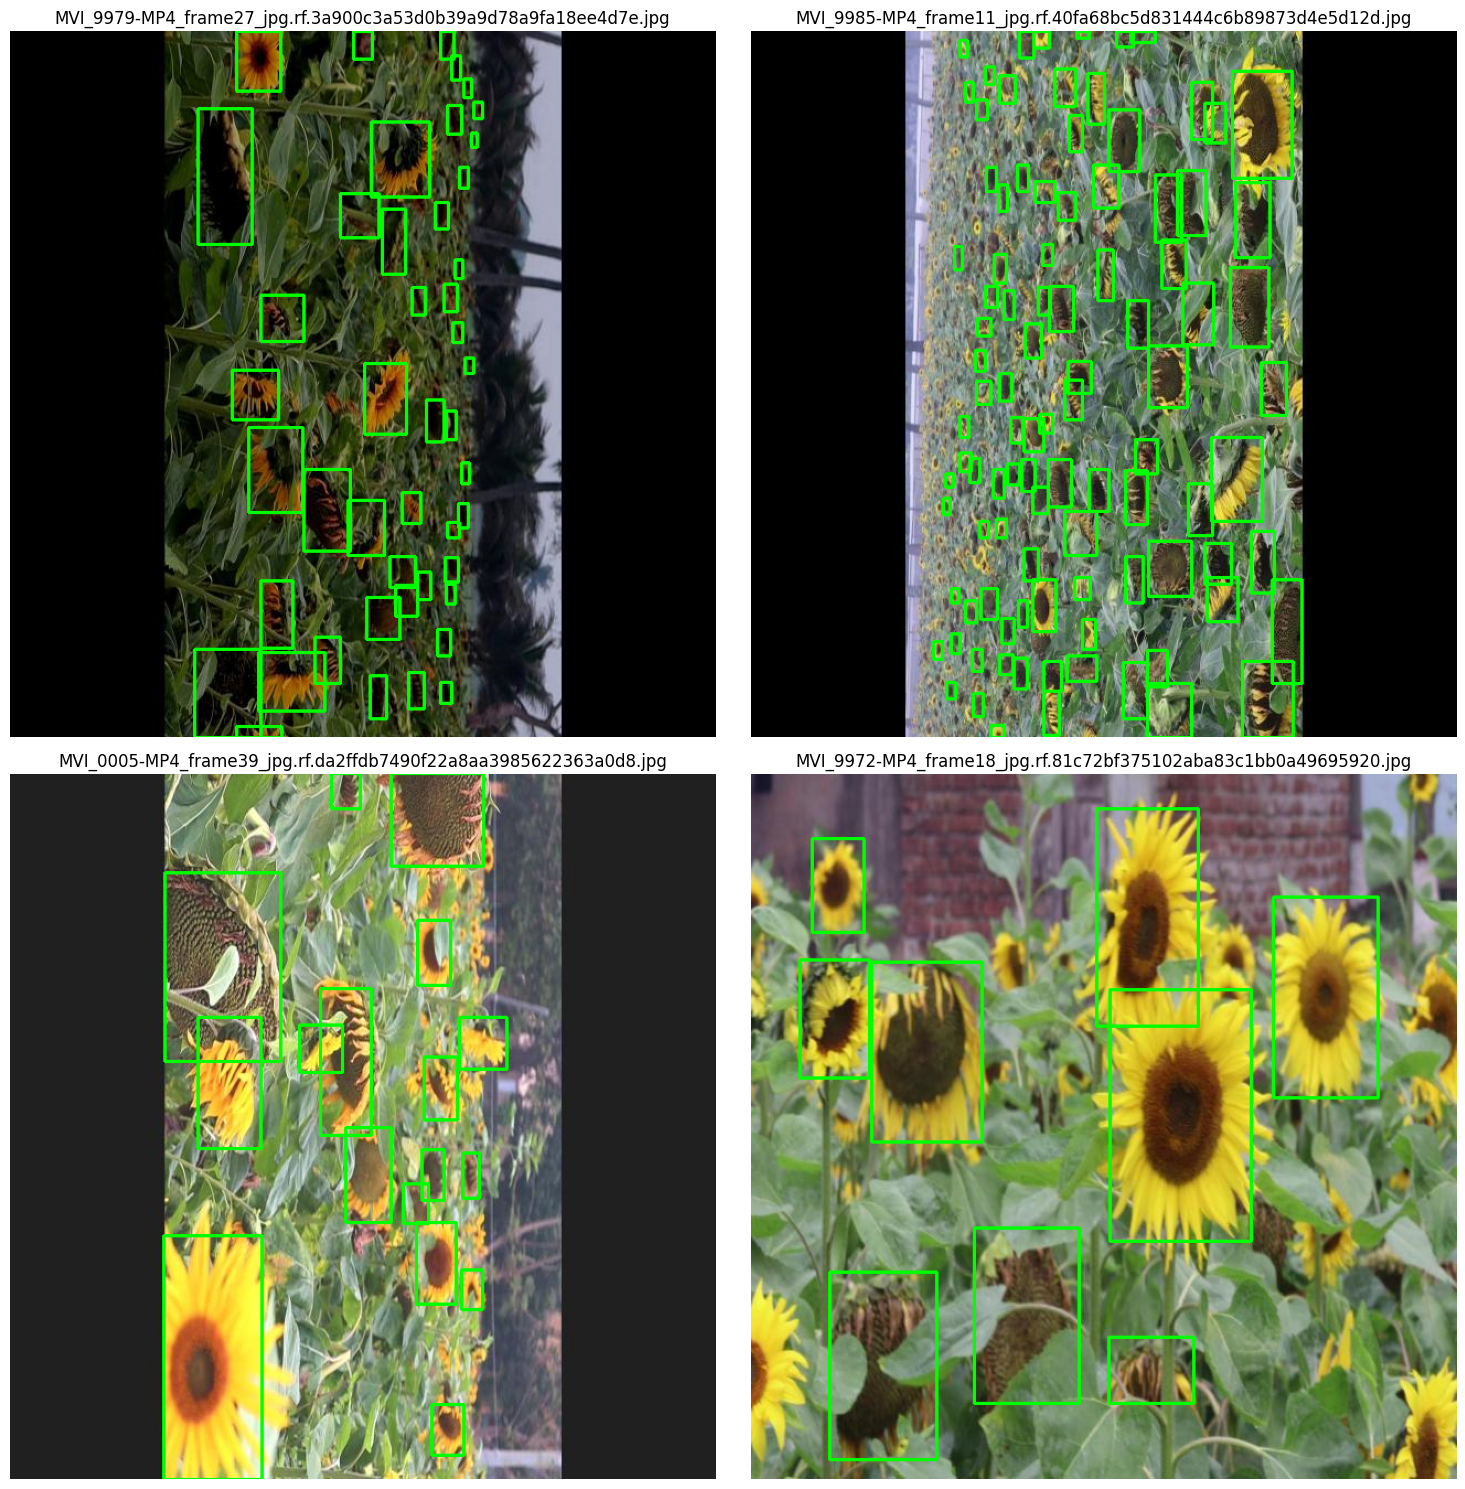

In [14]:
# Mostramos múltiples imágenes aleatorias con sus bounding boxes

fig, axes = plt.subplots(2, 2, figsize=(15, 15))

for ax in axes.flatten():

    image_name = random.choice(os.listdir(train_images_dir))

    image_path = os.path.join(train_images_dir, image_name)

    label_path = os.path.join(
        train_labels_dir,
        image_name.replace(".jpg", ".txt").replace(".png", ".txt")
    )

    # Leer imagen
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    img_height, img_width, _ = image.shape

    # Leer labels
    with open(label_path, "r") as file:
        labels = file.readlines()

    # Dibujar bounding boxes
    for label in labels:

        class_id, x_center, y_center, width, height = map(float, label.split())

        x_center *= img_width
        y_center *= img_height
        width *= img_width
        height *= img_height

        x1 = int(x_center - width / 2)
        y1 = int(y_center - height / 2)
        x2 = int(x_center + width / 2)
        y2 = int(y_center + height / 2)

        cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(image_name)

plt.tight_layout()
plt.show()

A partir de la inspección visual del dataset se observan distintas condiciones de captura, incluyendo variaciones de iluminación, escala y densidad de capítulos de girasol.

Además, se identifican escenarios desafiantes para el detector, tales como:
- objetos pequeños y lejanos,
- oclusiones parciales,
- superposición entre capítulos,
- variabilidad en orientación y perspectiva.

Estas características justifican la utilización de técnicas de Data Augmentation y el uso de modelos robustos de detección de objetos como YOLOv8.

#### **7. Análisis de Bounding Boxes**

En esta sección se analizan las anotaciones del dataset para comprender la densidad de objetos por imagen y el tamaño relativo de las bounding boxes. Este análisis permite identificar posibles desafíos para el modelo de detección, especialmente en escenarios con objetos pequeños o altamente agrupados.

In [15]:
bbox_per_image = []

for split in ["train", "valid", "test"]:

    labels_dir = os.path.join(dataset.location, split, "labels")

    for label_file in os.listdir(labels_dir):

        label_path = os.path.join(labels_dir, label_file)

        with open(label_path, "r") as file:
            lines = file.readlines()

        bbox_per_image.append(len(lines))

print(f"Cantidad promedio de bounding boxes por imagen: {sum(bbox_per_image)/len(bbox_per_image):.2f}")
print(f"Cantidad máxima de bounding boxes en una imagen: {max(bbox_per_image)}")
print(f"Cantidad mínima de bounding boxes en una imagen: {min(bbox_per_image)}")

Cantidad promedio de bounding boxes por imagen: 69.14
Cantidad máxima de bounding boxes en una imagen: 310
Cantidad mínima de bounding boxes en una imagen: 3


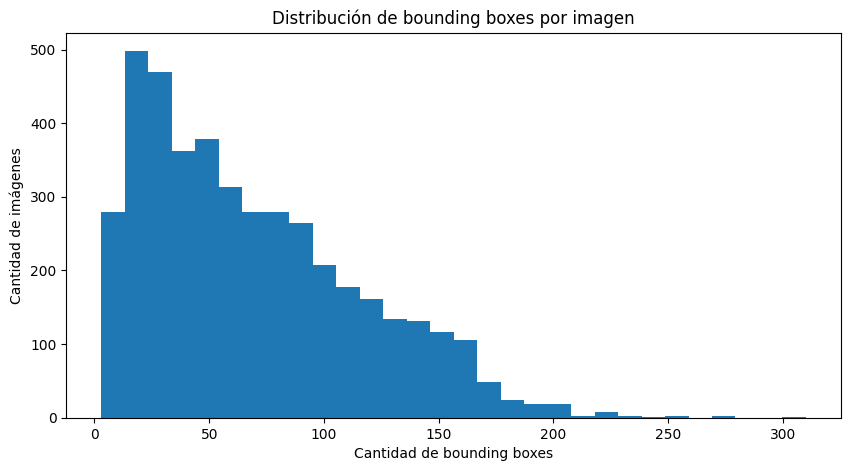

In [16]:
plt.figure(figsize=(10,5))

plt.hist(bbox_per_image, bins=30)

plt.title("Distribución de bounding boxes por imagen")
plt.xlabel("Cantidad de bounding boxes")
plt.ylabel("Cantidad de imágenes")

plt.show()

La distribución de bounding boxes por imagen evidencia una alta variabilidad en la densidad de objetos presentes en el dataset. La mayoría de las imágenes contienen entre 20 y 100 capítulos de girasol anotados, aunque existen casos extremos con más de 300 objetos en una única imagen.

Esto representa un escenario desafiante para el detector, especialmente en situaciones de alta densidad y superposición parcial entre objetos. Sin embargo, esta variabilidad también aporta realismo al dataset y favorece la capacidad de generalización del modelo.

**Tamaño relativo de las bounding boxes**

Se analiza la distribución del tamaño relativo de las bounding boxes para comprender si predominan objetos pequeños, medianos o grandes dentro del dataset. Este aspecto es especialmente relevante en modelos de detección de objetos, ya que los objetos pequeños suelen representar un mayor desafío para la detección automática.

In [17]:
bbox_areas = []

for split in ["train", "valid", "test"]:

    labels_dir = os.path.join(dataset.location, split, "labels")

    for label_file in os.listdir(labels_dir):

        label_path = os.path.join(labels_dir, label_file)

        with open(label_path, "r") as file:
            lines = file.readlines()

        for line in lines:

            class_id, x_center, y_center, width, height = map(float, line.split())

            area = width * height

            bbox_areas.append(area)

print(f"Área mínima: {min(bbox_areas):.6f}")
print(f"Área máxima: {max(bbox_areas):.6f}")
print(f"Área promedio: {sum(bbox_areas)/len(bbox_areas):.6f}")

Área mínima: 0.000007
Área máxima: 0.336792
Área promedio: 0.002612


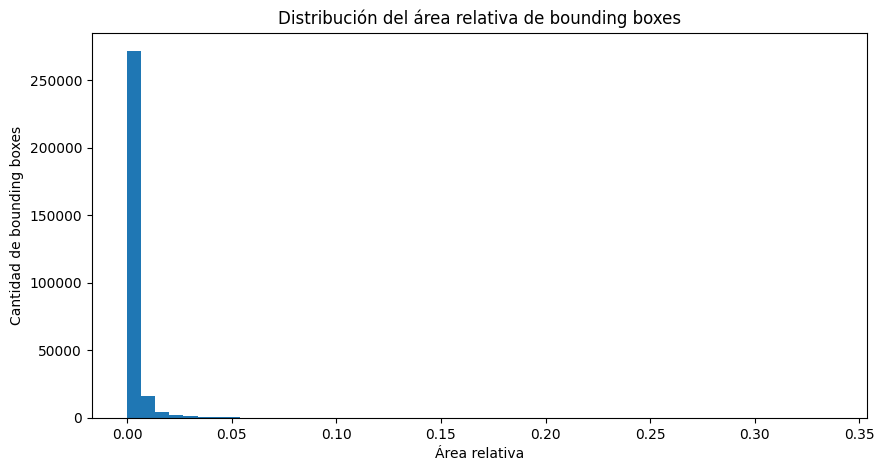

In [18]:
plt.figure(figsize=(10,5))

plt.hist(bbox_areas, bins=50)

plt.title("Distribución del área relativa de bounding boxes")
plt.xlabel("Área relativa")
plt.ylabel("Cantidad de bounding boxes")

plt.show()

La distribución del área relativa de las bounding boxes muestra una fuerte concentración de objetos pequeños dentro del dataset. La mayoría de los capítulos de girasol ocupan una porción reducida de la imagen, especialmente en escenas capturadas a mayor distancia o con alta densidad de cultivo.

Este comportamiento representa un desafío relevante para los modelos de detección de objetos, ya que los objetos pequeños suelen afectar negativamente métricas como recall y mAP. En consecuencia, este análisis justifica la utilización de arquitecturas modernas de detección y la evaluación de distintas resoluciones de entrada durante el entrenamiento.

#### **8. Conclusiones del EDA**

A partir del análisis exploratorio realizado sobre el dataset de capítulos de girasol, se obtuvieron las siguientes observaciones principales:

- El dataset presenta una **estructura compatible con YOLOv8** y una correcta correspondencia entre imágenes y archivos de anotación, facilitando su utilización en tareas de detección de objetos.

- Se identificó una **alta variabilidad visual** entre imágenes, incluyendo cambios de iluminación, perspectiva, escala y densidad de capítulos, lo cual aporta realismo al problema y favorece la capacidad de generalización del modelo.

- La distribución de clases evidencia un **fuerte desbalance** entre `Sunflower` y `Backside-Sunflower`, siendo la primera la clase ampliamente predominante. Debido al objetivo principal del proyecto, se evaluará simplificar el problema a una única clase durante el entrenamiento.

- El dataset contiene una **elevada densidad de objetos por imagen**, alcanzando casos con más de 300 bounding boxes simultáneas. Esto representa un escenario desafiante para la detección automática debido a posibles oclusiones y superposición entre objetos.

- El análisis del área relativa de las bounding boxes mostró que **predominan objetos pequeños**, característica que puede impactar negativamente métricas como recall y mAP, especialmente en escenas complejas o capturadas a gran distancia.

- Las observaciones obtenidas justifican la utilización de técnicas de Data Augmentation y el uso de arquitecturas modernas de detección de objetos como YOLOv8, priorizando modelos robustos para escenarios agrícolas reales.